In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, ifft2, fftshift
from scipy.signal import convolve2d, fftconvolve
from Functions import *

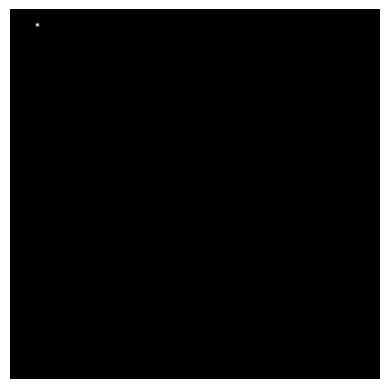

In [76]:
(p, q) = (5, 9)
# (p2, q2) = (10, 14)
# (p2, q2) = (10, 14)
Fhat = np.zeros((128, 128))
Fhat[p, q] = 1
# Fhat[p2, q2] = 1

showgrey(Fhat)

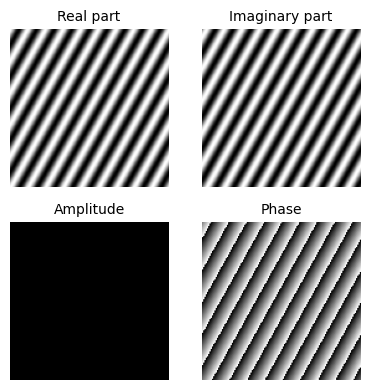

In [51]:
F = ifft2(Fhat)

Fabsmax = np.max(np.abs(F))

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize= (4, 4))
ax1.set_title("Real part")
ax2.set_title("Imaginary part")
ax3.set_title("Amplitude")
ax4.set_title("Phase")

plt.sca(ax1); showgrey(np.real(F), False, 64, -Fabsmax, Fabsmax)
plt.sca(ax2); showgrey(np.imag(F), False, 64, -Fabsmax, Fabsmax)
plt.sca(ax3); showgrey(np.abs(F), False, 64, -Fabsmax, Fabsmax)
plt.sca(ax4); showgrey(np.angle(F), False, 64, -np.pi, np.pi)

plt.tight_layout()
plt.show()


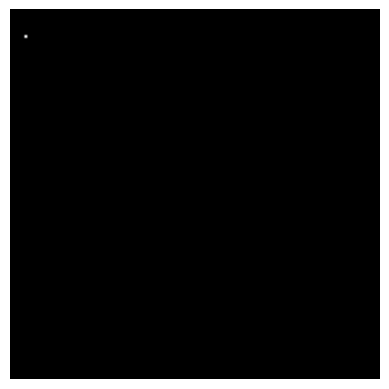

In [30]:
# (p, q) = (5, 9)
(p, q) = (9, 5)
# (p2, q2) = (10, 14)
# (p2, q2) = (10, 14)
Fhat = np.zeros((128, 128))
Fhat[p, q] = 1
# Fhat[p2, q2] = 1

showgrey(Fhat)

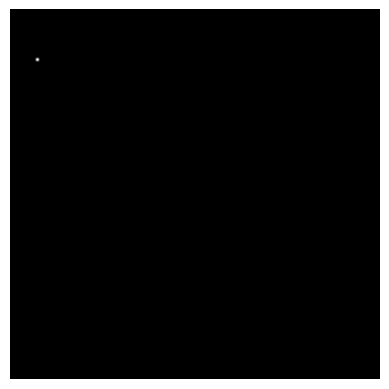

In [29]:
# (p, q) = (5, 9)
(p, q) = (17, 9)
# (p2, q2) = (10, 14)
# (p2, q2) = (10, 14)
Fhat = np.zeros((128, 128))
Fhat[p, q] = 1
# Fhat[p2, q2] = 1

showgrey(Fhat)

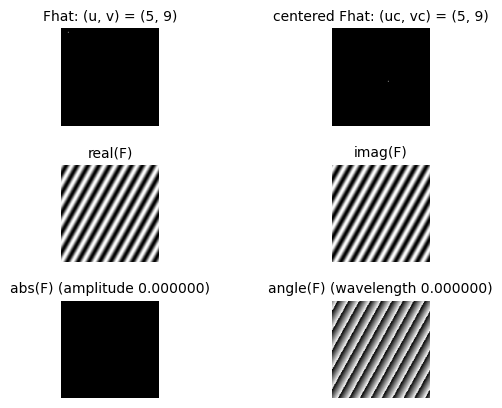

In [77]:
from fftwave import fftwave
F = ifft2(Fhat)
Fabsmax = np.max(np.abs(F))

# showgrey(np.real(F), True, 64, -Fabsmax, Fabsmax)
# showgrey(np.imag(F), True, 64, -Fabsmax, Fabsmax)
# showgrey(np.abs(F), True, 64, -Fabsmax, Fabsmax)
# showgrey(np.angle(F), True, 64, -np.pi, np.pi)

fftwave(5, 9, sz = 128)

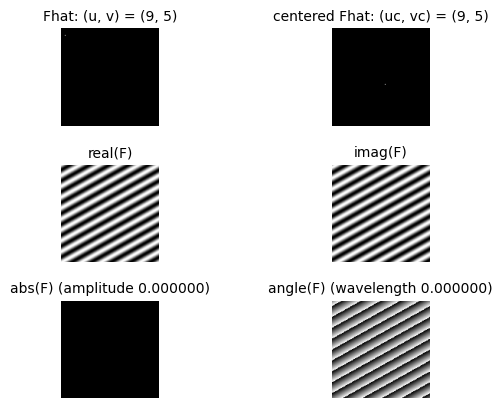

In [25]:
from fftwave import fftwave
F = ifft2(Fhat)
Fabsmax = np.max(np.abs(F))

# showgrey(np.real(F), True, 64, -Fabsmax, Fabsmax)
# showgrey(np.imag(F), True, 64, -Fabsmax, Fabsmax)
# showgrey(np.abs(F), True, 64, -Fabsmax, Fabsmax)
# showgrey(np.angle(F), True, 64, -np.pi, np.pi)

# fftwave(5, 9, sz = 128)
fftwave(9,5, sz = 128)

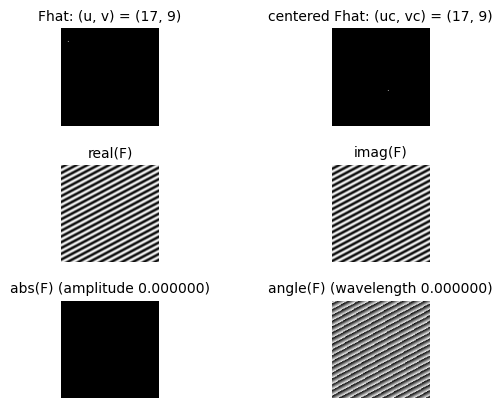

In [27]:
fftwave(17,9, sz = 128)

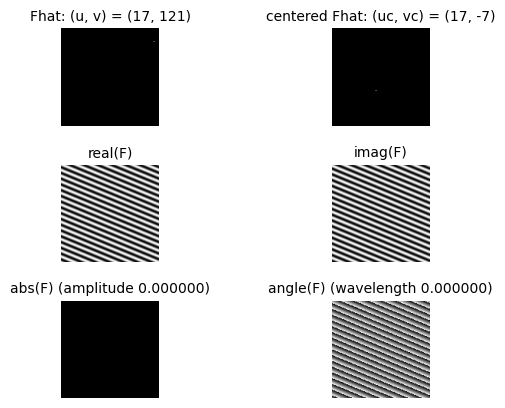

In [28]:
fftwave(17,121, sz = 128)

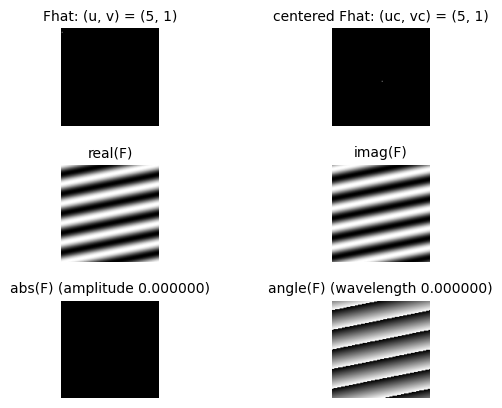

In [58]:
fftwave(5,1, sz = 128)

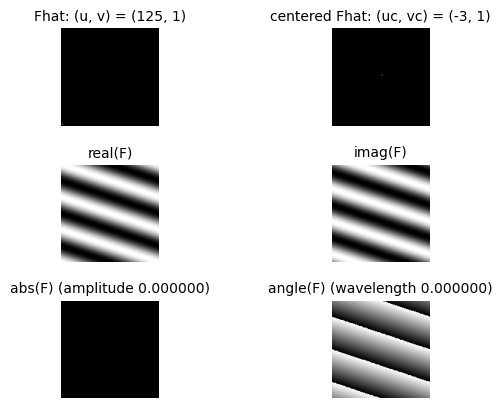

In [59]:
fftwave(125,1, sz = 128)

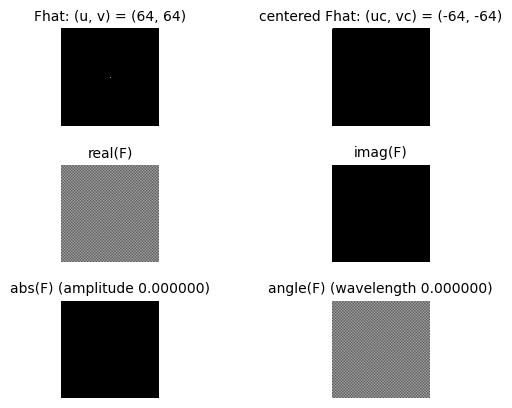

In [37]:
fftwave(64,64, sz = 128)

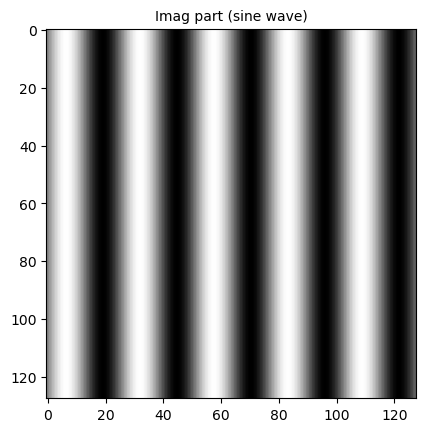

In [73]:
# Question 2:

# (u, v) = (0, 0)   # first test case, no frequency in y or x. Constant value everywhere.
# Fhat = np.zeros((128, 128)) 
# Fhat[u, v] = 1
# F = ifft2(Fhat)
# amp = np.max(np.abs(F))      # close to 0

# phase = np.angle(F)     # 0 

# Fhat = amp * np.exp(1j * phase)
# # same as:
# Fhat2 = np.real(F) + 1j * np.imag(F)

# # print("F: ", F)
# print("Amplitude: ", amp)
# print("Phase: ", phase)

# print(np.array_equal(Fhat, Fhat2))
# fftwave(0,1, sz = 128)

(p, q) = (0, 5)      # all rows are the same, no change 
Fhat = np.zeros((128, 128)) 
Fhat[p, q] = 1
F = ifft2(Fhat)
amp = np.max(np.abs(F))      

phase = np.angle(F)     

Fhat = amp * np.exp(1j * phase)     # reconstructed Fhat
# same as:
Fhat2 = np.real(F) + 1j * np.imag(F)

sine_wave = np.imag(F)
# cos_wave = np.real(F)
plt.imshow(sine_wave, cmap='gray')
plt.title("Imag part (sine wave)")
plt.show()


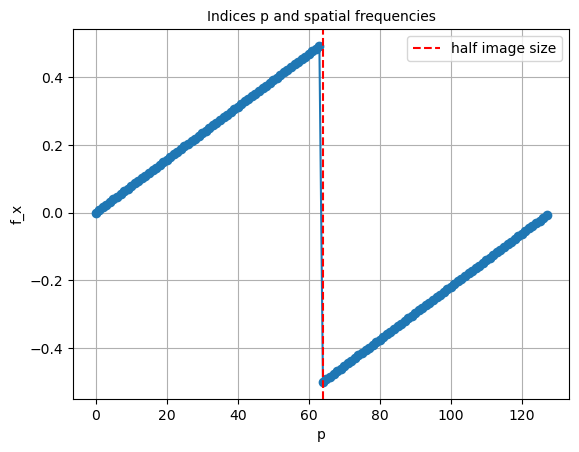

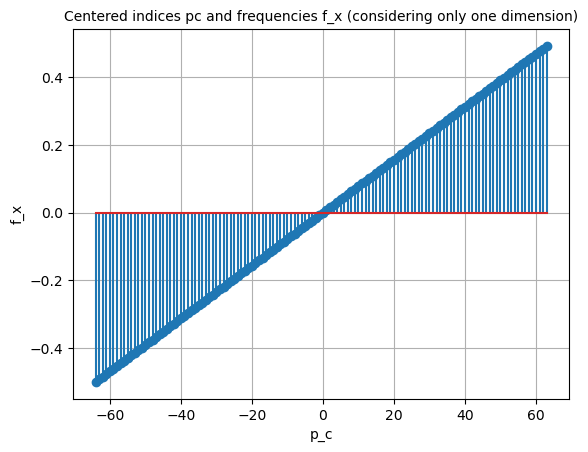

In [132]:
# 5)

sz = 128
p = np.arange(sz)        # indices

# centered indices 
pc = np.where(p < sz/2, p, p - sz)    # when p < sz/2, yield p, otherwise yield p - sz

# spatial frequencies
fx = pc / sz

plt.plot(p, fx, marker='o')
plt.axvline(sz/2, linestyle='--', color='red', label='half image size')
plt.title("Indices p and spatial frequencies")
plt.xlabel("p")
plt.ylabel("f_x")
plt.legend()
plt.grid(True)
plt.show()

# plt.plot(pc, fx, marker='o')
plt.stem(pc, fx)
plt.title("Centered indices pc and frequencies f_x (considering only one dimension)")
plt.xlabel("p_c")
plt.ylabel("f_x")
plt.grid(True)
plt.show()



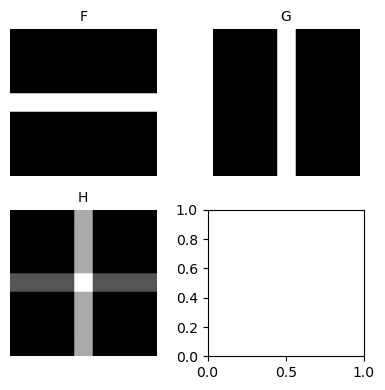

In [ ]:
# 7 and forward, linearity:
F = np.concatenate([np.zeros((56,128)), np.ones((16,128)), np.zeros((56,128))])
G = F.T
H = F + 2*G

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize= (4, 4))
ax1.set_title("F")
ax2.set_title("G")
ax3.set_title("H")

plt.sca(ax1); showgrey(F, display=False)
plt.sca(ax2); showgrey(G, display=False)
plt.sca(ax3); showgrey(H, display=False)

plt.tight_layout()
plt.show()

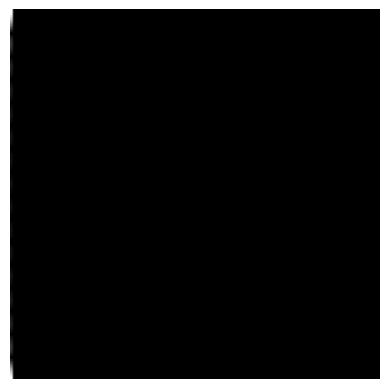

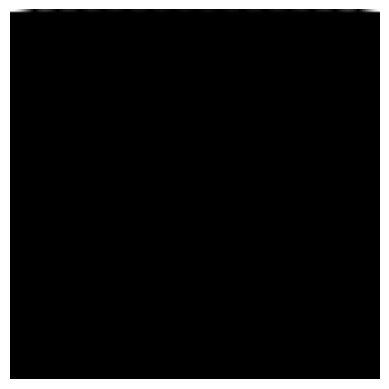

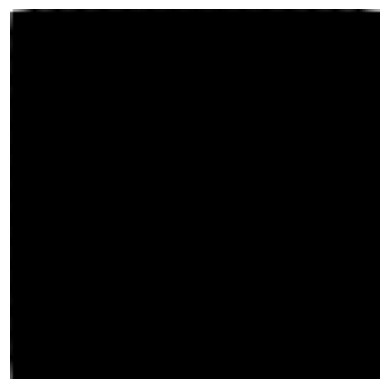

In [142]:
Fhat = fft2(F)
Ghat = fft2(G)
Hhat = fft2(H)

# showgrey(np.log(1 + np.abs(Fhat)))
# showgrey(np.log(1 + np.abs(Ghat)))
# showgrey(np.log(1 + np.abs(Hhat)))

showgrey(np.abs(Fhat))
showgrey(np.abs(Ghat))
showgrey(np.abs(Hhat))

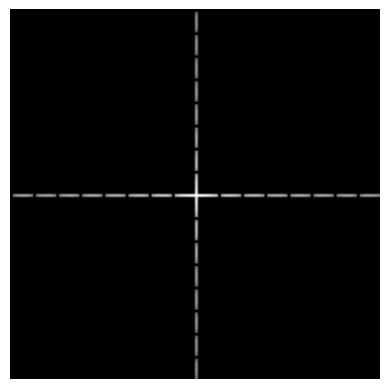

In [141]:
showgrey(np.log(1 + np.abs(fftshift(Hhat))))

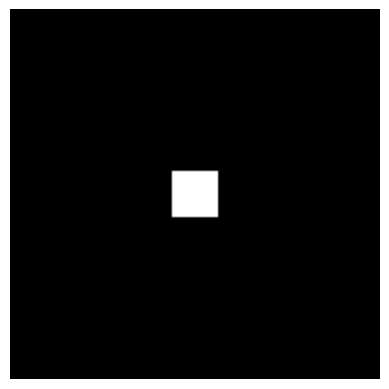

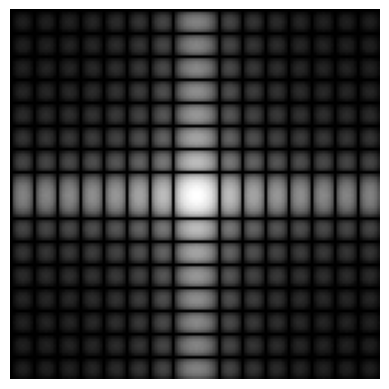

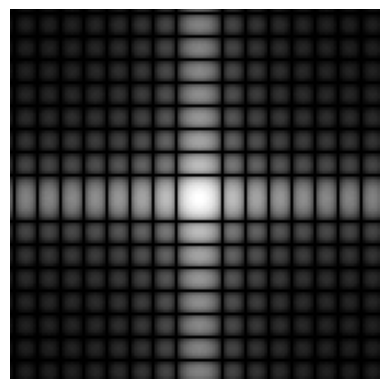

In [130]:
# 10, multiplication:

# The Fourier transform of a rectangle is a sinc function:
# A horizontal bar -> a vertical sinc pattern.
# A vertical bar -> a horizontal sinc pattern.

# Small in spatial domain -> Large spread in frequency domain.
# Square shape in space -> Sinc-like ripples in both directions (x and y)

F = np.concatenate([np.zeros((56,128)), np.ones((16,128)), np.zeros((56,128))])
G = F.T

showgrey(F * G)    # point-wise multiplication in spatial domain

# showfs shows the magnitude spectrum of the Fourier transform, with log scaling for better visibility
showfs(fft2(F * G))    # The Fourier transform of a 2d rectangle is a sinc function.   

# The sinc function has a peak at zero frequency (DC component) and oscillations that decay as frequency increases


# Multiplication in space corresponds to Convolution in frequency
Fhat = fft2(F)
Ghat = fft2(G)
Hhat = convolve2d(Fhat, Ghat, boundary="wrap", mode="same")   
showfs((fftshift(Hhat)) / (F.shape[0] * F.shape[1]))  # divide number of pixels, because convolve2d does sum of products, not scaled by the number of pixels


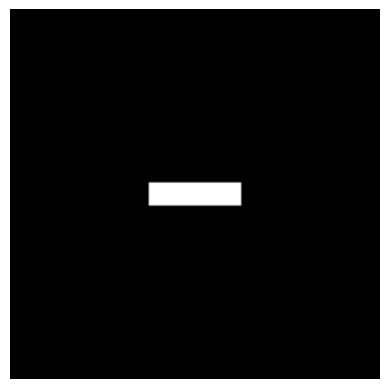

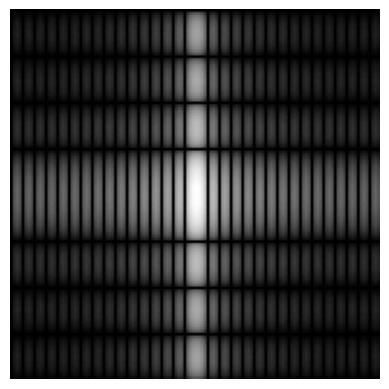

In [64]:
# 11, scaling:

F = np.concatenate([np.zeros((60,128)), np.ones((8,128)), np.zeros((60,128))]) * \
    np.concatenate([np.zeros((128,48)), np.ones((128,32)), np.zeros((128,48))], axis=1)
    

showgrey(F)

F_hat = fft2(F)

showfs(F_hat)

# Expansion in the spatial domain corresponds to compression in the Fourier domain. 
# Since the square was enlarged in the x axis, the Fourier transformed is compressed in the y dimension.

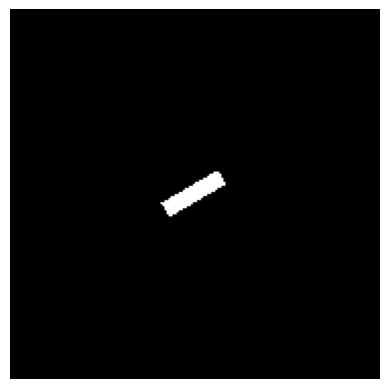

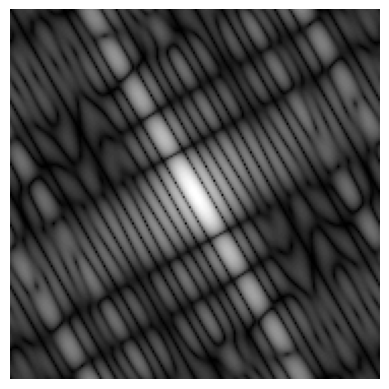

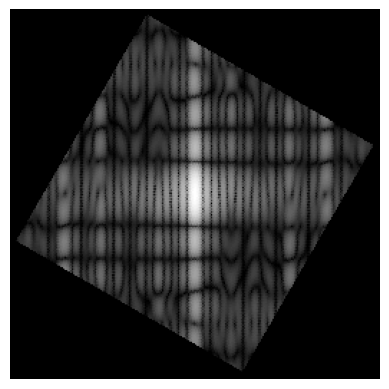

In [65]:
# 12, rotation: 
alpha = 30
G = rot(F, alpha)

Ghat = fft2(G)

plt.figure(1)

showgrey(G, display=False)

plt.show()

plt.figure(2)
showfs(Ghat, display=False)

plt.show()

plt.figure(3)
Hhat = rot(fftshift(Ghat), -alpha)

showgrey(np.log(1 + abs(Hhat)), display=False)
plt.show()

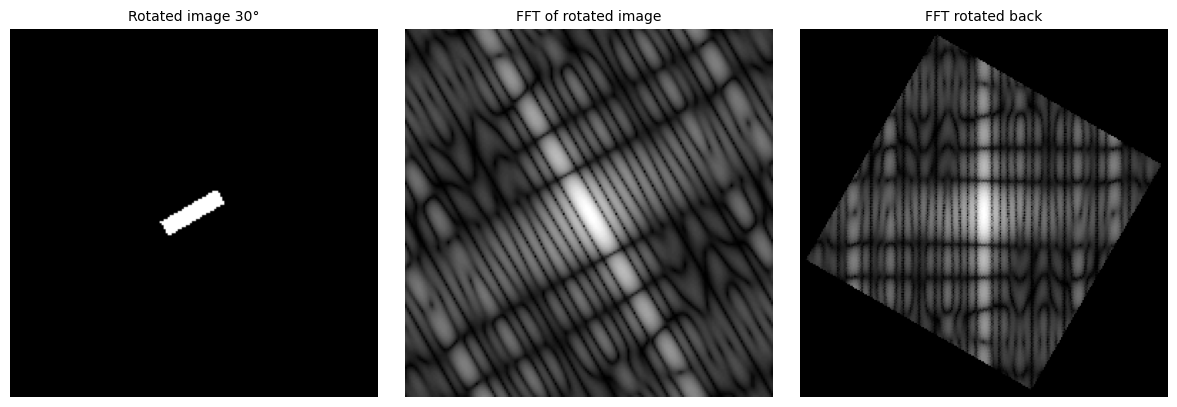

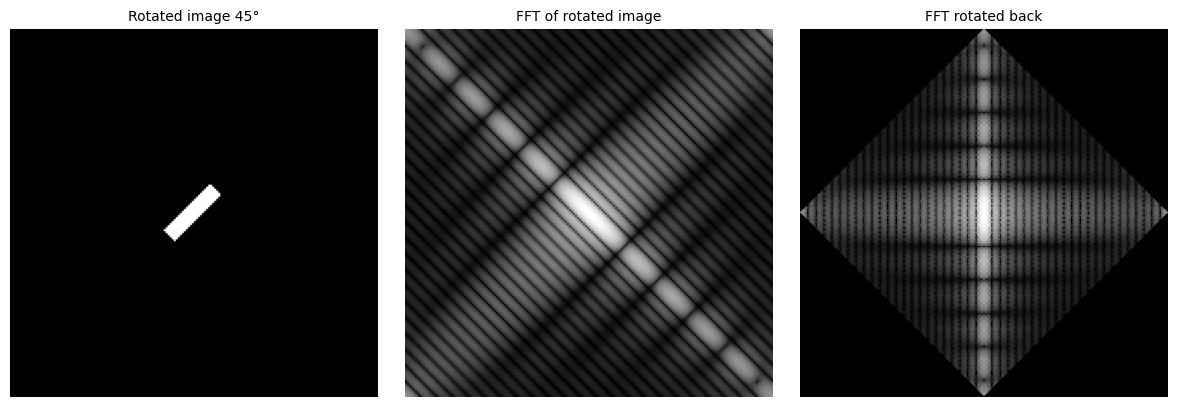

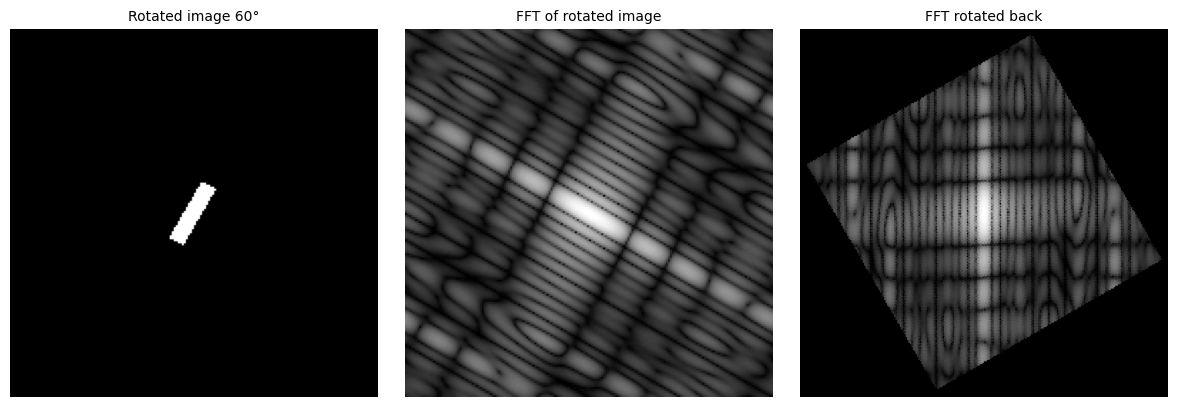

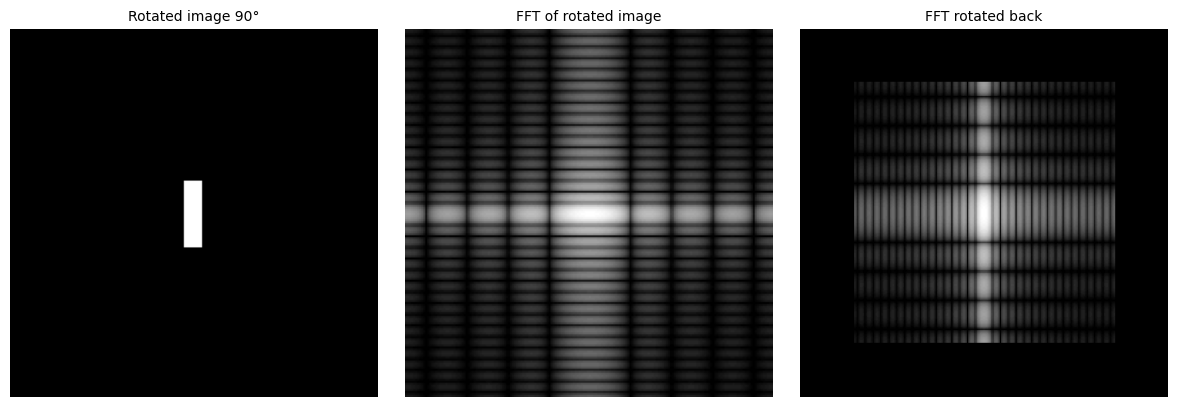

In [178]:
angles = [30, 45, 60, 90]

for alpha in angles:
    # Rotate the image
    G = rot(F, alpha)  # rotated image

    # Compute Fourier transform
    Ghat = fft2(G)

    # Rotate the Fourier spectrum back
    Hhat = rot(fftshift(Ghat), -alpha)

    plt.figure(figsize=(12,4))

    # Rotated image
    plt.subplot(1,3,1)
    showgrey(G, display=False)
    plt.title(f'Rotated image {alpha}°')

    # FFT of rotated image
    plt.subplot(1,3,2)
    showfs(Ghat, display=False)
    plt.title('FFT of rotated image')

    # Rotated FFT back
    plt.subplot(1,3,3)
    showgrey(np.log(1 + abs(Hhat)), display=False)
    plt.title('FFT rotated back')

    plt.tight_layout()
    plt.show()

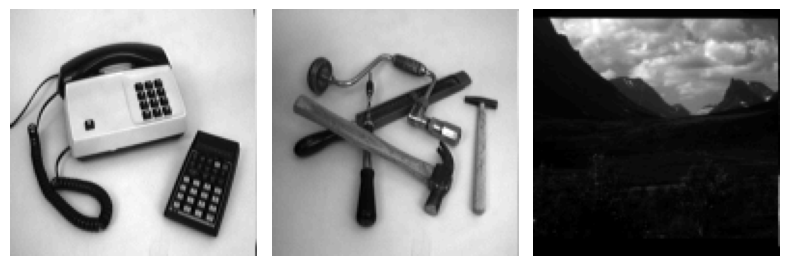

In [194]:
img = np.load("Images-npy/phonecalc128.npy")
img2 = np.load("Images-npy/few128.npy")
img3 = np.load("Images-npy/nallo128.npy")

plt.figure(figsize=(8, 6))

plt.subplot(1, 3, 1)
showgrey(img, display=False)

plt.subplot(1, 3, 2)
showgrey(img2, display=False)

plt.subplot(1, 3, 3)
showgrey(img3, display=False)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Randphaseimage nallo128')

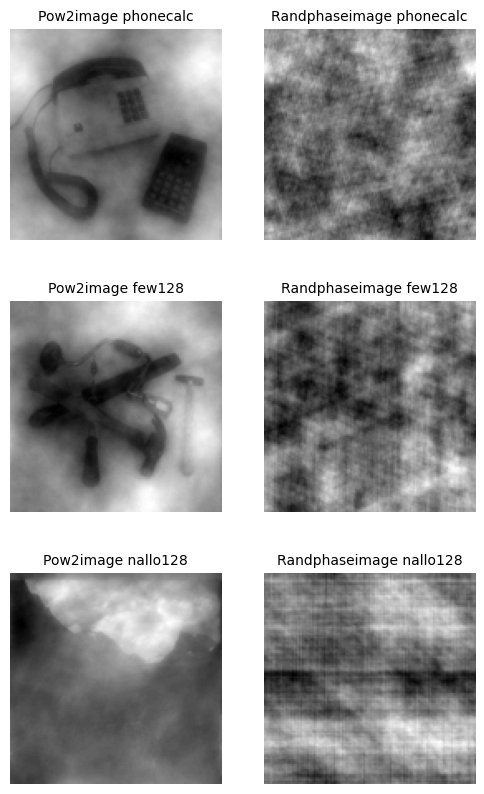

In [190]:
img = np.load("Images-npy/phonecalc128.npy")
img2 = np.load("Images-npy/few128.npy")
img3 = np.load("Images-npy/nallo128.npy")

plt.figure(figsize=(6, 10))

plt.subplot(3, 2, 1)
showgrey(pow2image(img), display=False)
plt.title('Pow2image phonecalc')
plt.axis('off')

plt.subplot(3, 2, 2)
showgrey(randphaseimage(img), display=False)
plt.title('Randphaseimage phonecalc')

plt.subplot(3, 2, 3)
showgrey(pow2image(img2), display=False)
plt.title('Pow2image few128')
plt.axis('off')

plt.subplot(3, 2, 4)
showgrey(randphaseimage(img2), display=False)
plt.title('Randphaseimage few128')

plt.subplot(3, 2, 5)
showgrey(pow2image(img3), display=False)
plt.title('Pow2image nallo128')
plt.axis('off')

plt.subplot(3, 2, 6)
showgrey(randphaseimage(img3), display=False)
plt.title('Randphaseimage nallo128')



In [102]:
# 14 and forward, Gaussian convolution implemented via FFT:

# Filter based on a sampled version of the Gaussian function:
def gaussian_kernel(t, shape):      # t is variance
    # uncentered gaussian kernel!
    sigma = np.sqrt(t)
    h, w = shape
    
    # to get a discrete filter, we sample the continuous Gaussian at integer coordinates (m, n) 
    
    # Integer grid for sampling, set step length to 1
    m = np.arange(-w//2, w//2)              # get 0 in center
    n = np.arange(-h//2, h//2)
    # m = np.arange(w)
    # n = np.arange(h)
    M, N = np.meshgrid(m, n)
    
    # Sample the continuous Gaussian at integer coordinates
    g = (1 / (2 * np.pi * t)) * np.exp(-(M**2 + N**2) / (2 * t))
    
    # Normalize so discrete sum equals 1
    return g / g.sum() 

In [215]:
# step length = 1
def gaussian_convolution(f_in):
    shape = f_in.shape
    t = 1         
    g = gaussian_kernel(t, shape)
    # f_out = sum wrt m sub wrt n (f_in(x-m, y-n))gaussian_kernel(t)
    f_out = convolve2d(f_in, g, mode='same', boundary='symm')
    
    return f_out

In [103]:
def gaussfft(pic, t):
    h, w = pic.shape      
    
    g = gaussian_kernel(t, pic.shape)
    g = np.fft.ifftshift(g)  # shift the center to (0,0) for FFT
    
    # f_hat = np.fft.fft2(np.fft.fftshift(pic))    # center image before fft
    # g_hat = np.fft.fft2(np.fft.fftshift(g))   # center kernel before fft
    
    f_hat = np.fft.fft2(pic)
    g_hat = np.fft.fft2(g)
    
    # convolution in spatial domain = multiplication in Fourier domain
    f_hat_out = f_hat * g_hat
    
    f_out = np.fft.ifft2(f_hat_out)    # maybe only take real part?
    
    return np.real(f_out)    # to get rid of floating point rounding errors of im part

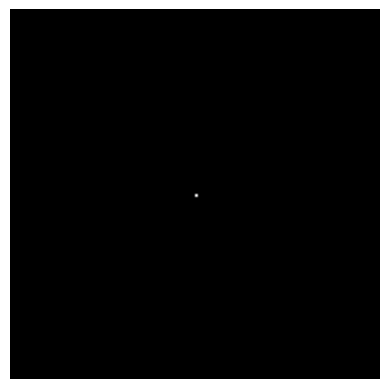

In [68]:
test_im = deltafcn(128, 128)
showgrey(test_im)

Covariance matrix for t = 0.1: [[1.32967252e-02 2.94209102e-15]
 [2.94209102e-15 1.32967252e-02]] 

Difference from ideal continuous case covariance for t = 0.1:  [[ 8.67032748e-02 -2.94209102e-15]
 [-2.94209102e-15  8.67032748e-02]] 

Covariance matrix for t = 0.3: [[2.8105383e-01 3.1918912e-14]
 [3.1918912e-14 2.8105383e-01]] 

Difference from ideal continuous case covariance for t = 0.3:  [[ 1.89461699e-02 -3.19189120e-14]
 [-3.19189120e-14  1.89461699e-02]] 

Covariance matrix for t = 1.0: [[9.99999789e-01 1.00475184e-14]
 [1.00475184e-14 9.99999789e-01]] 

Difference from ideal continuous case covariance for t = 1.0:  [[ 2.11227165e-07 -1.00475184e-14]
 [-1.00475184e-14  2.11227199e-07]] 

Covariance matrix for t = 10.0: [[ 1.00000000e+01 -3.44169138e-15]
 [-3.44169138e-15  1.00000000e+01]] 

Difference from ideal continuous case covariance for t = 10.0:  [[-2.02149408e-12  3.44169138e-15]
 [ 3.44169138e-15 -1.89004368e-12]] 

Covariance matrix for t = 100.0: [[9.99999993e+01 2.13

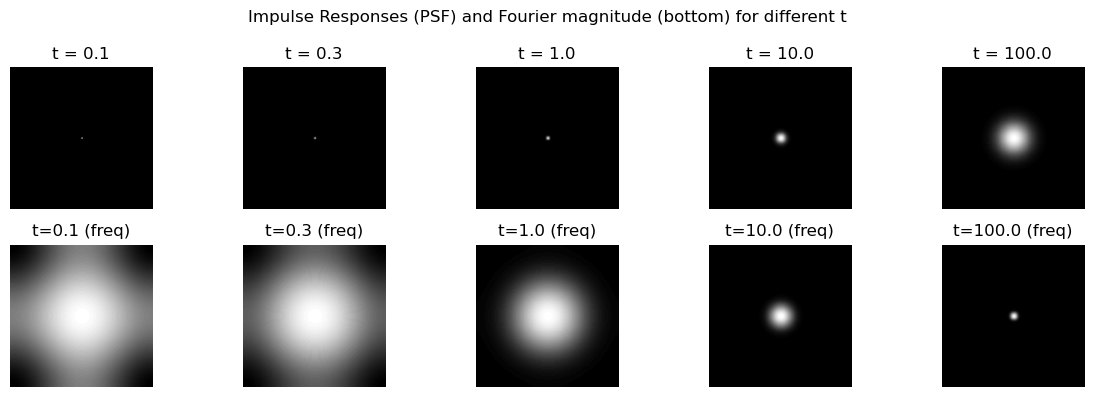

In [107]:
# 14
t_values = [0.1, 0.3, 1.0, 10.0, 100.0]
fig, axes = plt.subplots(2, len(t_values), figsize=(12, 4))

for i, t in enumerate(t_values):
    psf = gaussfft(deltafcn(128, 128), t)
    cov_matrix = variance(psf)
    print(f"Covariance matrix for t = {t}: {cov_matrix} \n")
    
    ideal_cov_matrix = np.array([[t, 0], [0, t]])
    
    print(f"Difference from ideal continuous case covariance for t = {t}:  {ideal_cov_matrix - cov_matrix} \n")

    plt.sca(axes[0, i]) 
    showgrey(psf, display=False)
    axes[0, i].set_title(f"t = {t}")
    
    plt.sca(axes[1, i]) 
    showfs(np.fft.fft2(psf), display = False)
    axes[1, i].set_title(f"t={t} (freq)")


plt.suptitle("Impulse Responses (PSF) and Fourier magnitude (bottom) for different t")
plt.tight_layout()
plt.show()

In [ ]:
# 15)

# t is the variance of the Gaussian
# deltafcn is a discrete delta at the center


# The difference from the ideal continuous covariance is largest for small t (where the difference in variance is around $8.67e-02$). 
# As t increases, the difference from the ideal continuous covariance is reduced, so they are very similar 
# (especially for t=10 for some reason, maybe because of some numerical errors or wrap-around that happens close to the border). 
# But the trend is that for large t's, the discrete approximation is better (because it covers more pixels and approximates the continuous case better). 

# We can see in image that a "wide" Gaussian (with a large value of t) in the spatial domain is very narrow in the Fourier domain, 
# which essentially means that it filters out large frequency (keeps only the low frequencies in the middle), 
# and for small values of t, we have a very large spread in the Fourier domain where we keep almost everything 
# (but maybe filters out some of the worst noise at the highest frequencies). 
# So, wide Gaussian in space (large t, that approximates the ideal continuous case well) is narrow in the Fourier domain 
# which makes it act kind of like an ideal lowpass filter.


# small t: narrow Gaussian, makes the discrete result very similar to the continuous
# large t: spreads out a lot in the grid, but is "cut off" near the grid edge, so the difference is larger
# with a large t the filter mostly captures low-frequency components (because the inverse relationship between width in space and width in Fourier domain
# as t increases, the Fourier transform becomes narrower

# "wide gaussian", large t: lowpass filter
# "narrow gaussian", small t: just blurs the image?

Covariance matrix for t = 1.0: [[1403.96526852  -32.41590563]
 [ -32.41590563 1497.0697367 ]] 

Difference from ideal continuous case covariance for t = 1.0:  [[-1402.96526852    32.41590563]
 [   32.41590563 -1496.0697367 ]] 

Covariance matrix for t = 4.0: [[1404.11346222  -36.91380504]
 [ -36.91380504 1490.39180827]] 

Difference from ideal continuous case covariance for t = 4.0:  [[-1400.11346222    36.91380504]
 [   36.91380504 -1486.39180827]] 

Covariance matrix for t = 16.0: [[1402.89054722  -47.82742499]
 [ -47.82742499 1475.20118125]] 

Difference from ideal continuous case covariance for t = 16.0:  [[-1386.89054722    47.82742499]
 [   47.82742499 -1459.20118125]] 

Covariance matrix for t = 64.0: [[1395.50849677  -63.65042117]
 [ -63.65042117 1440.65898797]] 

Difference from ideal continuous case covariance for t = 64.0:  [[-1331.50849677    63.65042117]
 [   63.65042117 -1376.65898797]] 

Covariance matrix for t = 256.0: [[1378.51147574  -47.11831645]
 [ -47.11831645 1378

/Users/kajsalidin/Desktop/DD2423_image_analysis/DD2423_Python_Labs_1_2/Functions.py:46: ComplexWarning: Casting complex values to real discards the imaginary part
  im = res*(Image.astype(np.float32) - zmin)/float(range)
/Users/kajsalidin/Desktop/DD2423_image_analysis/DD2423_Python_Labs_1_2/Functions.py:49: ComplexWarning: Casting complex values to real discards the imaginary part
  plt.imshow(np.array(im, dtype=np.uint8), cmap)


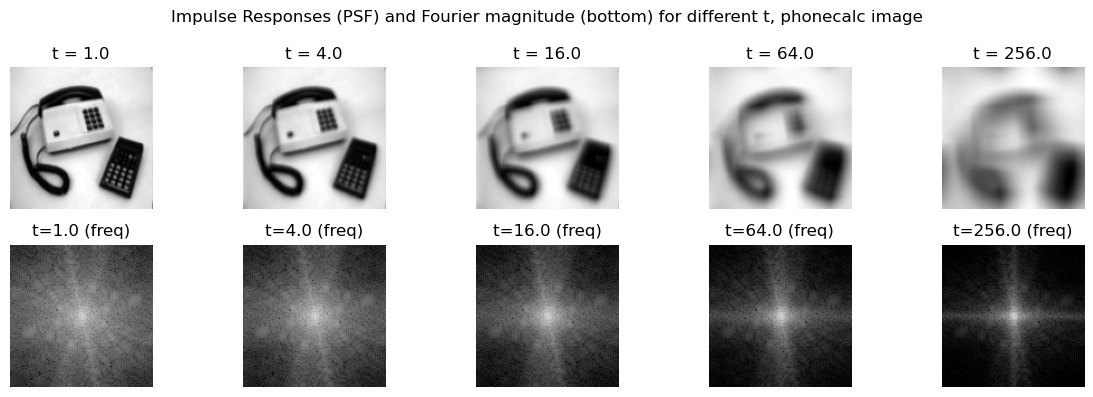

In [6]:
t_values = [1.0, 4.0, 16.0, 64.0, 256.0]
fig, axes = plt.subplots(2, len(t_values), figsize=(12, 4))

img = np.load("Images-npy/phonecalc128.npy")

for i, t in enumerate(t_values):
    psf = gaussfft(img, t)
    cov_matrix = variance(psf)
    print(f"Covariance matrix for t = {t}: {cov_matrix} \n")
    
    ideal_cov_matrix = np.array([[t, 0], [0, t]])
    
    print(f"Difference from ideal continuous case covariance for t = {t}:  {ideal_cov_matrix - cov_matrix} \n")

    plt.sca(axes[0, i]) 
    showgrey(psf, display=False)
    axes[0, i].set_title(f"t = {t}")
    
    plt.sca(axes[1, i]) 
    showfs(np.fft.fft2(psf), display = False)
    axes[1, i].set_title(f"t={t} (freq)")


plt.suptitle("Impulse Responses (PSF) and Fourier magnitude (bottom) for different t, phonecalc image")
plt.tight_layout()
plt.show()

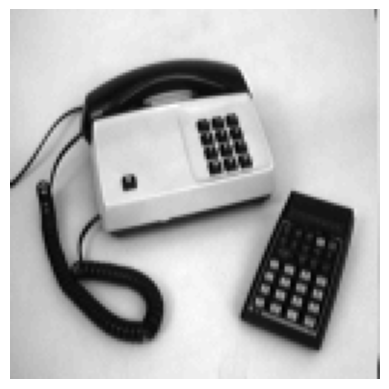

In [231]:
showgrey(img, display=False)

Covariance matrix for t = 1.0: [[1404.26186866   23.30121195]
 [  23.30121195 1571.2086062 ]] 

Difference from ideal continuous case covariance for t = 1.0:  [[-1403.26186866   -23.30121195]
 [  -23.30121195 -1570.2086062 ]] 

Covariance matrix for t = 4.0: [[1415.13364666   23.4293269 ]
 [  23.4293269  1570.9030847 ]] 

Difference from ideal continuous case covariance for t = 4.0:  [[-1411.13364666   -23.4293269 ]
 [  -23.4293269  -1566.9030847 ]] 

Covariance matrix for t = 16.0: [[1434.98785842   20.47381788]
 [  20.47381788 1568.67008736]] 

Difference from ideal continuous case covariance for t = 16.0:  [[-1418.98785842   -20.47381788]
 [  -20.47381788 -1552.67008736]] 

Covariance matrix for t = 64.0: [[1465.24524548    8.02505273]
 [   8.02505273 1557.73413541]] 

Difference from ideal continuous case covariance for t = 64.0:  [[-1401.24524548    -8.02505273]
 [   -8.02505273 -1493.73413541]] 

Covariance matrix for t = 256.0: [[1491.21254285  -17.20359362]
 [ -17.20359362 1517

/Users/kajsalidin/Desktop/DD2423_image_analysis/DD2423_Python_Labs_1_2/Functions.py:46: ComplexWarning: Casting complex values to real discards the imaginary part
  im = res*(Image.astype(np.float32) - zmin)/float(range)
/Users/kajsalidin/Desktop/DD2423_image_analysis/DD2423_Python_Labs_1_2/Functions.py:49: ComplexWarning: Casting complex values to real discards the imaginary part
  plt.imshow(np.array(im, dtype=np.uint8), cmap)


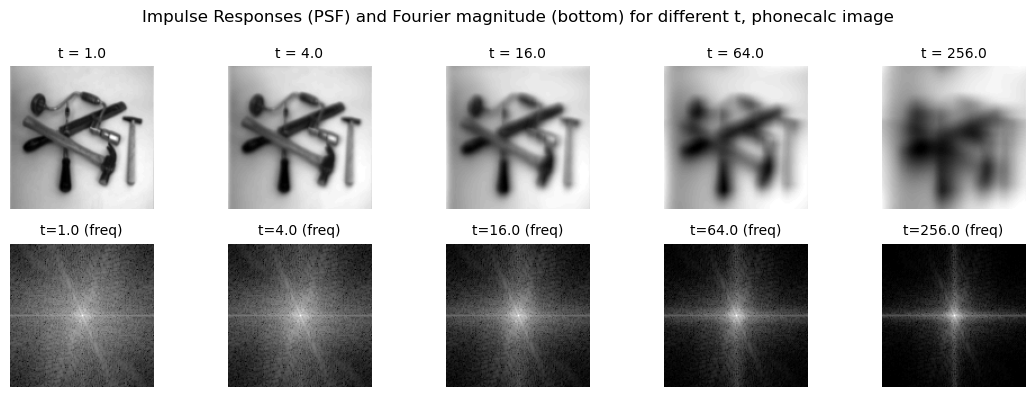

In [229]:
img2 = np.load("Images-npy/few128.npy")

for i, t in enumerate(t_values):
    psf = gaussfft(img2, t)
    cov_matrix = variance(psf)
    print(f"Covariance matrix for t = {t}: {cov_matrix} \n")
    
    ideal_cov_matrix = np.array([[t, 0], [0, t]])
    
    print(f"Difference from ideal continuous case covariance for t = {t}:  {ideal_cov_matrix - cov_matrix} \n")

    plt.sca(axes[0, i]) 
    showgrey(psf, display=False)
    axes[0, i].set_title(f"t = {t}")
    
    plt.sca(axes[1, i]) 
    showfs(np.fft.fft2(psf), display = False)
    axes[1, i].set_title(f"t={t} (freq)")


plt.suptitle("Impulse Responses (PSF) and Fourier magnitude (bottom) for different t, phonecalc image")
plt.tight_layout()
plt.show()

Covariance matrix for t = 1.0: [[967.62049856  60.56207701]
 [ 60.56207701 543.86425444]] 

Difference from ideal continuous case covariance for t = 1.0:  [[-966.62049856  -60.56207701]
 [ -60.56207701 -542.86425444]] 

Covariance matrix for t = 4.0: [[975.82293624  47.27222825]
 [ 47.27222825 545.03416453]] 

Difference from ideal continuous case covariance for t = 4.0:  [[-971.82293624  -47.27222825]
 [ -47.27222825 -541.03416453]] 

Covariance matrix for t = 16.0: [[993.38893329  36.82353744]
 [ 36.82353744 549.01715301]] 

Difference from ideal continuous case covariance for t = 16.0:  [[-977.38893329  -36.82353744]
 [ -36.82353744 -533.01715301]] 

Covariance matrix for t = 64.0: [[1032.64673038   28.8131693 ]
 [  28.8131693   557.09807604]] 

Difference from ideal continuous case covariance for t = 64.0:  [[-968.64673038  -28.8131693 ]
 [ -28.8131693  -493.09807604]] 

Covariance matrix for t = 256.0: [[1127.51037712   28.05446982]
 [  28.05446982  582.44400994]] 

Difference fro

/Users/kajsalidin/Desktop/DD2423_image_analysis/DD2423_Python_Labs_1_2/Functions.py:46: ComplexWarning: Casting complex values to real discards the imaginary part
  im = res*(Image.astype(np.float32) - zmin)/float(range)
/Users/kajsalidin/Desktop/DD2423_image_analysis/DD2423_Python_Labs_1_2/Functions.py:49: ComplexWarning: Casting complex values to real discards the imaginary part
  plt.imshow(np.array(im, dtype=np.uint8), cmap)


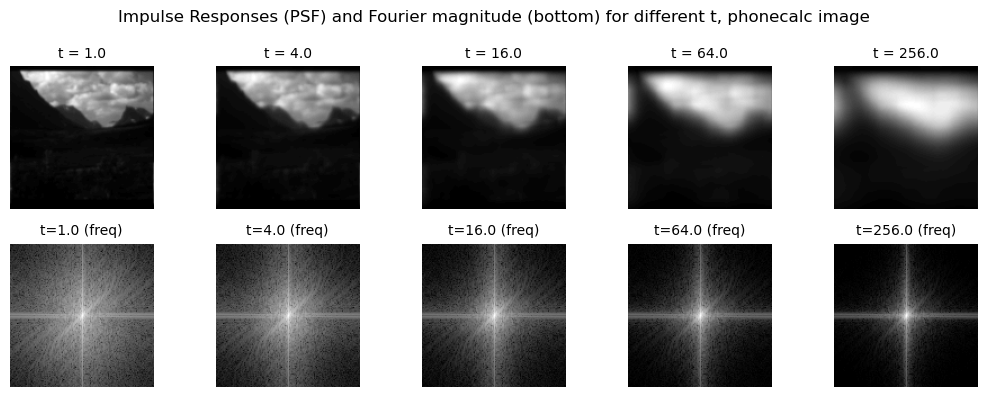

In [230]:
img3 = np.load("Images-npy/nallo128.npy")

for i, t in enumerate(t_values):
    psf = gaussfft(img3, t)
    cov_matrix = variance(psf)
    print(f"Covariance matrix for t = {t}: {cov_matrix} \n")
    
    ideal_cov_matrix = np.array([[t, 0], [0, t]])
    
    print(f"Difference from ideal continuous case covariance for t = {t}:  {ideal_cov_matrix - cov_matrix} \n")

    plt.sca(axes[0, i]) 
    showgrey(psf, display=False)
    axes[0, i].set_title(f"t = {t}")
    
    plt.sca(axes[1, i]) 
    showfs(np.fft.fft2(psf), display = False)
    axes[1, i].set_title(f"t={t} (freq)")


plt.suptitle("Impulse Responses (PSF) and Fourier magnitude (bottom) for different t, phonecalc image")
plt.tight_layout()
plt.show()

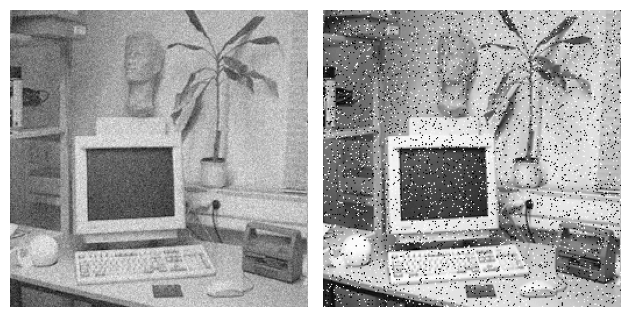

In [5]:
# 17 and forward, Smoothing:

office = np.load("Images-npy/office256.npy")

add = gaussnoise(office, 16)    # gaussian noise
sap = sapnoise(office, 0.1, 255)    # salt-and-pepper noise

ax1 = plt.subplot(1, 2, 1)
plt.sca(ax1)
showgrey(add, display=False)
ax2 = plt.subplot(1, 2, 2)
plt.sca(ax2)
showgrey(sap, display=False)

plt.tight_layout()
plt.show()

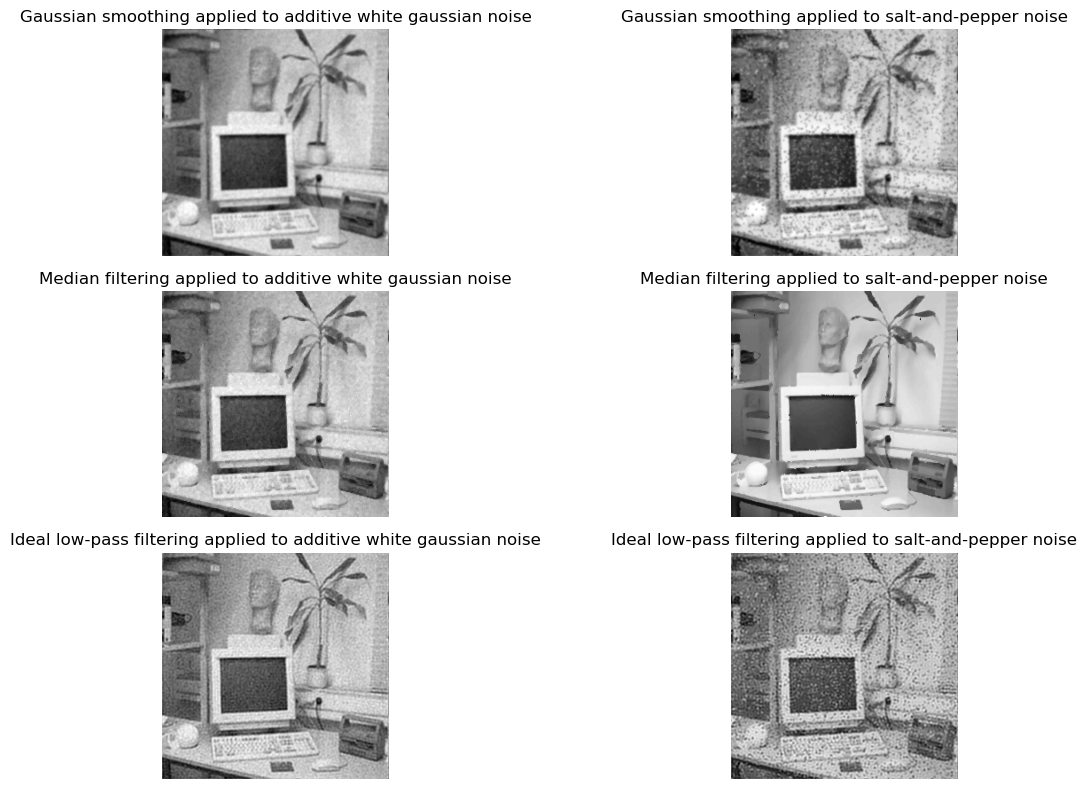

In [109]:
# gauss_smoothed_1 = discgaussfft(add, sigma2=1.0)
gauss_smoothed_1 = gaussfft(add, t=1.0)
gauss_smoothed_2 = gaussfft(sap, t=1.0)

median_filtered_1 = medfilt(add, wheight=3, wwidth=3)
median_filtered_2 = medfilt(sap, wheight=3, wwidth=3)

# median_filtered_1 = medfilt(add, wheight=10, wwidth=10)
# median_filtered_2 = medfilt(sap, wheight=10, wwidth=10)

# ringing effects for cutoff=0.1
# ideal_low_pass_filtered_1 = ideal(add, cutoff=0.1)     # cutoff = 0.5 corresponds to the Nyquist limit - the highest cutoff frequency we can have
# ideal_low_pass_filtered_2 = ideal(sap, cutoff=0.1)

ideal_low_pass_filtered_1 = ideal(add, cutoff=0.3)     # cutoff = 0.5 corresponds to the Nyquist limit, all content kept
ideal_low_pass_filtered_2 = ideal(sap, cutoff=0.3)

plt.figure(figsize=(15, 8))
ax1 = plt.subplot(3, 2, 1)
plt.sca(ax1)
showgrey(gauss_smoothed_1, display=False)
ax1.set_title("Gaussian smoothing applied to additive white gaussian noise")

ax2 = plt.subplot(3, 2, 2)
plt.sca(ax2)
showgrey(gauss_smoothed_2, display=False)
ax2.set_title("Gaussian smoothing applied to salt-and-pepper noise")

ax3 = plt.subplot(3, 2, 3)
plt.sca(ax3)
showgrey(median_filtered_1, display=False)
ax3.set_title("Median filtering applied to additive white gaussian noise")

ax4 = plt.subplot(3, 2, 4)
plt.sca(ax4)
showgrey(median_filtered_2, display=False)
ax4.set_title("Median filtering applied to salt-and-pepper noise")

ax3 = plt.subplot(3, 2, 5)
plt.sca(ax3)
showgrey(ideal_low_pass_filtered_1, display=False)
ax3.set_title("Ideal low-pass filtering applied to additive white gaussian noise")

ax4 = plt.subplot(3, 2, 6)
plt.sca(ax4)
showgrey(ideal_low_pass_filtered_2, display=False)
ax4.set_title("Ideal low-pass filtering applied to salt-and-pepper noise")

plt.tight_layout()
plt.show()

In [ ]:
# 17)
# - the Gaussian smoothing looks a little blurry with unsharp edges, more "averaged out", + but it reduces the high frequency noise
# Effective at removing the Gaussian (random) noise because it smoothes out the randomness. 
# However, if there is a lot of noise then you need a wide Gaussian (large t) and it’s hard to remove the noise without blurring the image too much. 
# That is, you quickly lose a lot of details, especially with edges

# + Median filtering looks less blurry in some ways (clearer intensitites), - but looks a bit artificial (especially for larger window sizes because that smooths out more)
# median filtering is the most efficient for salt-and-pepper noise

# - with the ideal lowpass filter, we sort of balance ringing effects and noise
# + but it is good at removing high frequency data in the image
# This is useful when working in the frequency domain, since high frequency data is found near the edges and can look like noise.
# However, this filter is ineffective at removing gaussian or S&P noise, since these types of noise are in the spacial domain.
# lower cutoff: more smoothing and ringing. higher: less smoothing and more noise.


# 18)
# Gaussian smoothing keeps general intensity trends but blurs out edges a bit so they are not so sharp
# Increasing the variance gives us more smoothing (essentially becoming similar to a low-pass filter), but more blurry
# it is better for Gaussian noise

# Median filtering was the only smoothing method that efficiently removed the sap noise, and edges look sharp and good
# looks painted though, especially with a large window size, small windows look better

# Ideal low-pass filtering removes noise at high frequencies, 
# but introduces some ringing patterns near edges because the discontinuity can't really be represented (we removed the frequencies that could handle that)
# smoother cutoff: less ringing but less noise reduction
# cutoff at 0.1 and 0.2 introduced ringing effects, but 0.3 was a good tradeoff


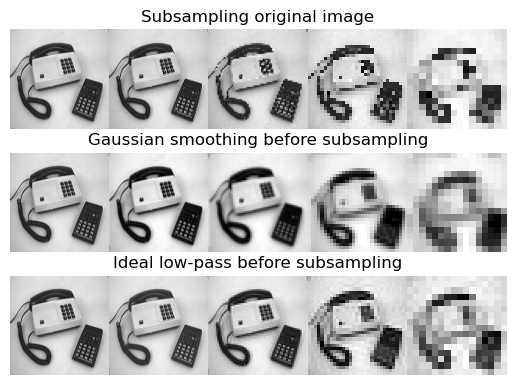

In [62]:
# subsampling without smoothing can introduce aliasing, while smoothing first prevents aliasing

img = np.load("Images-npy/phonecalc256.npy") 
smoothimg_gauss = img.copy()
smoothimg_ideal = img.copy()
N=5
f = plt.figure()
f.subplots_adjust(wspace=0, hspace=0)
for i in range(N):
    if i>0: # generate subsampled versions
        img = rawsubsample(img)
        # smoothimg = # <call_your_filter_here>(smoothimg, <params>)
        smoothimg_gauss = gaussfft(smoothimg_gauss, t=2)   # with t=0.5, some alising kept. t=1 and t=2 was good for not too blurry image
        smoothimg_gauss = rawsubsample(smoothimg_gauss)
        
        smoothimg_ideal = ideal(smoothimg_ideal, cutoff=0.3)     # 0.2 is kind of good for reducing aliasing but introduced some ringing, 0.3 chosen
        smoothimg_ideal = rawsubsample(smoothimg_ideal)
        
    f.add_subplot(3, N, i + 1)      # im 1 to 5
    showgrey(img, False)
    if i == N//2:    # place title in the middle
        plt.title("Subsampling original image")
    f.add_subplot(3, N, i + N + 1)     # im 6 to 10
    showgrey(smoothimg_gauss, False)
    if i == N//2:
        plt.title("Gaussian smoothing before subsampling")
    f.add_subplot(3, N, i + 2*N + 1)    # im 11 to 15
    showgrey(smoothimg_ideal, False)
    if i == N//2:
        plt.title("Ideal low-pass before subsampling")
plt.show()

In [ ]:
# when subsampling, we reduce the sampling rate
# frequency in the original image above the new Nyquist frequency are aliased (forced into lower dimensions, distorted)
# smoothing: reducing the high frequency components that would otherwise cause aliasing
# - but we lose some details by blurring and could get ringing effects